# Prediksi Harga Sepeda Motor Bekas Honda Menggunakan Regresi Linear Berganda

Notebook ini digunakan untuk membuat model prediksi harga sepeda motor bekas Honda berdasarkan spesifikasi kendaraan.  
Metode yang digunakan adalah **Regresi Linear Berganda** karena model memanfaatkan lebih dari satu variabel bebas untuk memprediksi harga.

## 1. Mengambil Dataset

Dataset diambil dari repository GitHub yang berisi data sepeda motor bekas Honda.

In [2]:
!git clone https://github.com/farrelaryansyah/predictive-analytics.git
%cd predictive-analytics

d:\SEMESTER 6\PIDB\JogjaMotor\predictive-analytics


Cloning into 'predictive-analytics'...


In [3]:
%pip install gdown -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
import gdown

file_id = "1-y6XXsoTLwaqOevLGh7DCxZGbTyaSBwO"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset_mofe.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1-y6XXsoTLwaqOevLGh7DCxZGbTyaSBwO
To: d:\SEMESTER 6\PIDB\JogjaMotor\predictive-analytics\dataset_mofe.csv
100%|██████████| 158k/158k [00:00<00:00, 2.09MB/s]


'dataset_mofe.csv'

## 2. Import Library

Library yang digunakan terdiri dari `pandas` dan `numpy` untuk pengolahan data, `matplotlib` untuk visualisasi, serta beberapa modul dari `scikit-learn` untuk pembuatan model.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

## 3. Membaca Dataset

In [6]:
df = pd.read_csv("dataset_mofe.csv")
df.head()

,Harga,Merk & Model,Tahun,Tipe / Varian,Jenis Transmisi,Warna,Jarak Tempuh,STNK,BPKB,Buku Servis
0,Rp 25.200.000,"Honda, ADV150",2019,CBS,Matic,Hitam,101.627 KM,Tersedia,Tersedia,Tersedia
1,Rp 21.800.000,"Honda, Vario125",2023,CBS,Matic,Hitam,11.000 KM,Tersedia,Tersedia,Tidak Tersedia
2,Rp 16.200.000,"Honda, SupraGTR150",2023,NaN,Cub,Hitam,97.172 KM,Tersedia,Tersedia,Tersedia
3,Rp 14.300.000,"Honda, BeATStreet",2023,NaN,Matic,Hitam,38.327 KM,Tersedia,Tersedia,Tersedia
4,Rp 26.900.000,"Honda, PCX160",2021,ABS,Matic,Merah,21.000 KM,Tersedia,Tersedia,Tidak Tersedia


In [7]:
print("Jumlah baris dan kolom:", df.shape)
print("\nNama kolom:")
print(df.columns)

Jumlah baris dan kolom: (1636, 10)

Nama kolom:
Index(['Harga', 'Merk & Model', 'Tahun', 'Tipe / Varian', 'Jenis Transmisi',
       'Warna', 'Jarak Tempuh', 'STNK', 'BPKB', 'Buku Servis'],
      dtype='object')


## 4. Memahami Kondisi Data

Pada tahap ini dilakukan pengecekan tipe data, data kosong, dan ringkasan statistik awal.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1636 entries, 0 to 1635
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Harga            1636 non-null   object
 1   Merk & Model     1636 non-null   object
 2   Tahun            1636 non-null   int64 
 3   Tipe / Varian    1238 non-null   object
 4   Jenis Transmisi  1636 non-null   object
 5   Warna            1636 non-null   object
 6   Jarak Tempuh     1636 non-null   object
 7   STNK             1636 non-null   object
 8   BPKB             1636 non-null   object
 9   Buku Servis      1636 non-null   object
dtypes: int64(1), object(9)
memory usage: 127.9+ KB


In [9]:
df.isnull().sum()

Harga                0
Merk & Model         0
Tahun                0
Tipe / Varian      398
Jenis Transmisi      0
Warna                0
Jarak Tempuh         0
STNK                 0
BPKB                 0
Buku Servis          0
dtype: int64

In [10]:
df.describe(include="all")

,Harga,Merk & Model,Tahun,Tipe / Varian,Jenis Transmisi,Warna,Jarak Tempuh,STNK,BPKB,Buku Servis
count,1636,1636,1636.000000,1238,1636,1636,1636,1636,1636,1636
unique,146,28,NaN,19,3,11,241,2,2,2
top,Rp 15.800.000,"Honda, BeAT",NaN,CBS,Matic,Hitam,10.000 KM,Tersedia,Tersedia,Tidak Tersedia
freq,77,485,NaN,527,1494,875,232,1501,1503,1541
mean,NaN,NaN,2021.371027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,2.820825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2023.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2023.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Membersihkan Data

Kolom `Harga` dan `Jarak Tempuh` masih berbentuk teks, sehingga perlu diubah menjadi angka.  
Contohnya `Rp 25.200.000` diubah menjadi `25200000`, dan `10.000 KM` diubah menjadi `10000`.

In [11]:
df_clean = df.copy()

df_clean["Harga"] = (
    df_clean["Harga"]
    .astype(str)
    .str.replace("Rp", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.strip()
)

df_clean["Jarak Tempuh"] = (
    df_clean["Jarak Tempuh"]
    .astype(str)
    .str.replace("KM", "", regex=False)
    .str.replace("km", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.strip()
)

df_clean["Harga"] = pd.to_numeric(df_clean["Harga"], errors="coerce")
df_clean["Jarak Tempuh"] = pd.to_numeric(df_clean["Jarak Tempuh"], errors="coerce")

df_clean.head()

,Harga,Merk & Model,Tahun,Tipe / Varian,Jenis Transmisi,Warna,Jarak Tempuh,STNK,BPKB,Buku Servis
0,25200000,"Honda, ADV150",2019,CBS,Matic,Hitam,101627,Tersedia,Tersedia,Tersedia
1,21800000,"Honda, Vario125",2023,CBS,Matic,Hitam,11000,Tersedia,Tersedia,Tidak Tersedia
2,16200000,"Honda, SupraGTR150",2023,NaN,Cub,Hitam,97172,Tersedia,Tersedia,Tersedia
3,14300000,"Honda, BeATStreet",2023,NaN,Matic,Hitam,38327,Tersedia,Tersedia,Tersedia
4,26900000,"Honda, PCX160",2021,ABS,Matic,Merah,21000,Tersedia,Tersedia,Tidak Tersedia


## 6. Menangani Data Kosong dan Duplikat

Data kosong pada kolom kategorikal diisi dengan modus, sedangkan data kosong pada kolom numerik diisi dengan median.  
Duplikat juga dihapus agar data yang digunakan lebih bersih.

In [12]:
kolom_numerik = ["Tahun", "Jarak Tempuh"]
kolom_kategori = [
    "Merk & Model",
    "Tipe / Varian",
    "Jenis Transmisi",
    "Warna",
    "STNK",
    "BPKB",
    "Buku Servis"
]

for kolom in kolom_numerik:
    df_clean[kolom] = df_clean[kolom].fillna(df_clean[kolom].median())

for kolom in kolom_kategori:
    df_clean[kolom] = df_clean[kolom].fillna(df_clean[kolom].mode()[0])

df_clean = df_clean.dropna(subset=["Harga"])
df_clean = df_clean.drop_duplicates()

df_clean.isnull().sum()

Harga              0
Merk & Model       0
Tahun              0
Tipe / Varian      0
Jenis Transmisi    0
Warna              0
Jarak Tempuh       0
STNK               0
BPKB               0
Buku Servis        0
dtype: int64

In [13]:
print("Ukuran data setelah dibersihkan:", df_clean.shape)
df_clean.head()

Ukuran data setelah dibersihkan: (1094, 10)


,Harga,Merk & Model,Tahun,Tipe / Varian,Jenis Transmisi,Warna,Jarak Tempuh,STNK,BPKB,Buku Servis
0,25200000,"Honda, ADV150",2019,CBS,Matic,Hitam,101627,Tersedia,Tersedia,Tersedia
1,21800000,"Honda, Vario125",2023,CBS,Matic,Hitam,11000,Tersedia,Tersedia,Tidak Tersedia
2,16200000,"Honda, SupraGTR150",2023,CBS,Cub,Hitam,97172,Tersedia,Tersedia,Tersedia
3,14300000,"Honda, BeATStreet",2023,CBS,Matic,Hitam,38327,Tersedia,Tersedia,Tersedia
4,26900000,"Honda, PCX160",2021,ABS,Matic,Merah,21000,Tersedia,Tersedia,Tidak Tersedia


## 7. Menentukan Variabel Bebas dan Variabel Target

Variabel target pada penelitian ini adalah `Harga`.  
Variabel bebas yang digunakan adalah spesifikasi kendaraan seperti tahun, model, tipe, transmisi, warna, jarak tempuh, dan kelengkapan dokumen.

In [14]:
X = df_clean[kolom_numerik + kolom_kategori]
y = df_clean["Harga"]

X.head()

,Tahun,Jarak Tempuh,Merk & Model,Tipe / Varian,Jenis Transmisi,Warna,STNK,BPKB,Buku Servis
0,2019,101627,"Honda, ADV150",CBS,Matic,Hitam,Tersedia,Tersedia,Tersedia
1,2023,11000,"Honda, Vario125",CBS,Matic,Hitam,Tersedia,Tersedia,Tidak Tersedia
2,2023,97172,"Honda, SupraGTR150",CBS,Cub,Hitam,Tersedia,Tersedia,Tersedia
3,2023,38327,"Honda, BeATStreet",CBS,Matic,Hitam,Tersedia,Tersedia,Tersedia
4,2021,21000,"Honda, PCX160",ABS,Matic,Merah,Tersedia,Tersedia,Tidak Tersedia


## 8. Membagi Data Training dan Testing

Data dibagi menjadi 80% data training dan 20% data testing.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing :", X_test.shape[0])

Jumlah data training: 875
Jumlah data testing : 219


## 9. Membuat Model Regresi Linear Berganda

Kolom kategorikal diubah menggunakan **One-Hot Encoding**.  
Cara ini lebih sesuai untuk regresi dibandingkan `LabelEncoder`, karena kategori seperti warna atau transmisi tidak memiliki urutan angka.

In [16]:
preprocess = ColumnTransformer(
    transformers=[
        ("kategori", OneHotEncoder(handle_unknown="ignore", drop="first"), kolom_kategori),
        ("numerik", "passthrough", kolom_numerik)
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regresi", LinearRegression())
    ]
)

## 10. Melatih Model

In [17]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('regresi', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Tahun','Jarak Tempuh','Merk & Model',...,'STNK','BPKB','Buku Servis']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('kategori', ...), ('numerik', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of 

In [30]:
print(model)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('kategori',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Merk & Model',
                                                   'Tipe / Varian',
                                                   'Jenis Transmisi', 'Warna',
                                                   'STNK', 'BPKB',
                                                   'Buku Servis']),
                                                 ('numerik', 'passthrough',
                                                  ['Tahun', 'Jarak Tempuh'])])),
                ('regresi', LinearRegression())])


In [31]:
print(model.named_steps)

{'preprocess': ColumnTransformer(transformers=[('kategori',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Merk & Model', 'Tipe / Varian',
                                  'Jenis Transmisi', 'Warna', 'STNK', 'BPKB',
                                  'Buku Servis']),
                                ('numerik', 'passthrough',
                                 ['Tahun', 'Jarak Tempuh'])]), 'regresi': LinearRegression()}


## 11. Melakukan Prediksi dan Evaluasi Model

In [18]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Hasil Evaluasi Model")
print("---------------------")
print(f"MAE  : Rp {mae:,.0f}")
print(f"MSE  : {mse:,.0f}")
print(f"RMSE : Rp {rmse:,.0f}")
print(f"R²   : {r2:.4f}")

Hasil Evaluasi Model
---------------------
MAE  : Rp 1,098,158
MSE  : 2,319,119,026,754
RMSE : Rp 1,522,865
R²   : 0.9068


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Nilai MAE menunjukkan rata-rata selisih antara harga asli dan harga prediksi.  
Nilai RMSE menunjukkan besar kesalahan prediksi dengan penalti lebih besar untuk error yang tinggi.  
Nilai R² menunjukkan seberapa besar variabel bebas mampu menjelaskan variasi harga motor bekas.

## 12. Membandingkan Harga Asli dan Harga Prediksi

In [19]:
hasil_prediksi = pd.DataFrame({
    "Harga Asli": y_test.values,
    "Harga Prediksi": y_pred,
    "Selisih": np.abs(y_test.values - y_pred)
})

hasil_prediksi["Harga Asli"] = hasil_prediksi["Harga Asli"].round(0).astype(int)
hasil_prediksi["Harga Prediksi"] = hasil_prediksi["Harga Prediksi"].round(0).astype(int)
hasil_prediksi["Selisih"] = hasil_prediksi["Selisih"].round(0).astype(int)

hasil_prediksi.head(10)

,Harga Asli,Harga Prediksi,Selisih
0,15500000,15817112,317112
1,13300000,12968249,331751
2,20000000,19796707,203293
3,5800000,10835872,5035872
4,12900000,11755319,1144681
5,9800000,10365172,565172
6,16200000,15278295,921705
7,13500000,14903922,1403922
8,15300000,16172045,872045
9,13300000,12409690,890310


## 13. Visualisasi Hasil Prediksi

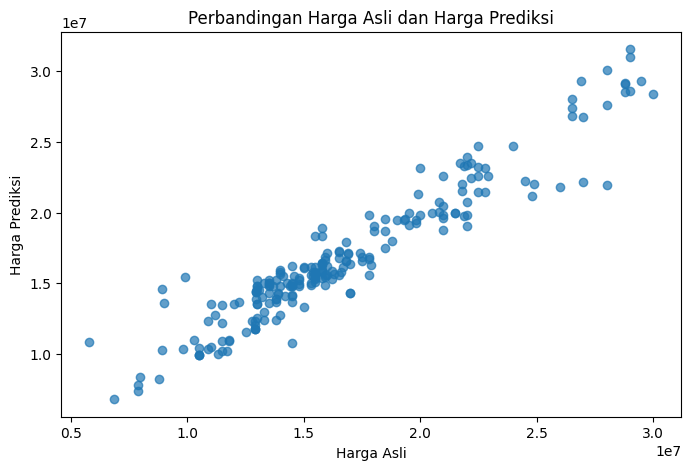

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Harga Asli")
plt.ylabel("Harga Prediksi")
plt.title("Perbandingan Harga Asli dan Harga Prediksi")
plt.show()

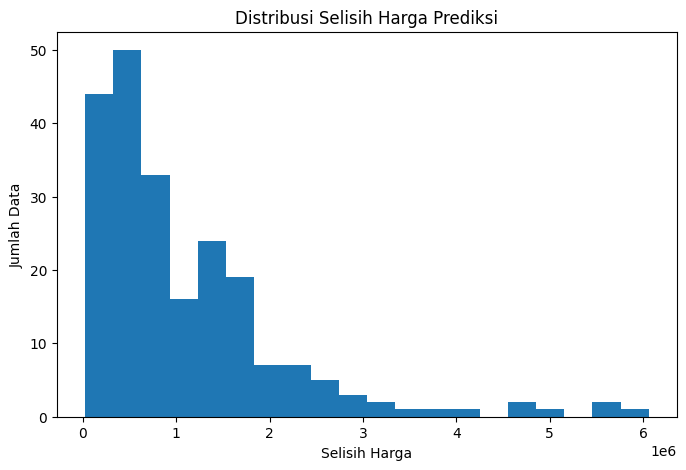

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(hasil_prediksi["Selisih"], bins=20)
plt.xlabel("Selisih Harga")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Selisih Harga Prediksi")
plt.show()

## 14. Menampilkan Koefisien Model

Koefisien digunakan untuk melihat pengaruh setiap variabel terhadap prediksi harga.

In [22]:
nama_fitur_kategori = model.named_steps["preprocess"] \
    .named_transformers_["kategori"] \
    .get_feature_names_out(kolom_kategori)

nama_fitur = list(nama_fitur_kategori) + kolom_numerik

koefisien = pd.DataFrame({
    "Variabel": nama_fitur,
    "Koefisien": model.named_steps["regresi"].coef_
})

koefisien.sort_values(by="Koefisien", ascending=False).head(10)

,Variabel,Koefisien
0,"Merk & Model_Honda, ADV160",7.196874e+06
8,"Merk & Model_Honda, CRF150L",6.865314e+06
41,Jenis Transmisi_Matic,5.766740e+06
12,"Merk & Model_Honda, PCX160",4.978669e+06
42,Jenis Transmisi_Sports,4.056073e+06
9,"Merk & Model_Honda, CT125",3.776732e+06
16,"Merk & Model_Honda, Stylo160",3.313714e+06
25,Tipe / Varian_ABS,2.490888e+06
11,"Merk & Model_Honda, PCX150",2.214582e+06
6,"Merk & Model_Honda, CB150X",2.206605e+06


In [23]:
print("Intercept:", model.named_steps["regresi"].intercept_)

Intercept: -1545470633.273143


## 15. Uji Prediksi pada Salah Satu Data Testing

In [24]:
contoh_data = X_test.iloc[[0]]
prediksi_contoh = model.predict(contoh_data)

print("Data yang diuji:")
display(contoh_data)

print("Harga asli      :", f"Rp {int(y_test.iloc[0]):,}")
print("Harga prediksi  :", f"Rp {int(prediksi_contoh[0]):,}")

Data yang diuji:


,Tahun,Jarak Tempuh,Merk & Model,Tipe / Varian,Jenis Transmisi,Warna,STNK,BPKB,Buku Servis
655,2020,40000,"Honda, Scoopy",CBS,Matic,Hitam,Tersedia,Tersedia,Tidak Tersedia


Harga asli      : Rp 15,500,000
Harga prediksi  : Rp 15,817,111


## 16. Menyimpan Model

Model disimpan dalam format `.pkl` agar dapat digunakan kembali tanpa melakukan training ulang.

In [25]:
joblib.dump(model, "model_regresi_linear_motor_bekas.pkl")
print("Model berhasil disimpan.")

Model berhasil disimpan.


## Kesimpulan

Model Regresi Linear Berganda berhasil dibuat untuk memprediksi harga sepeda motor bekas Honda berdasarkan spesifikasi kendaraan.  
Fitur yang digunakan meliputi tahun, jarak tempuh, model, tipe, transmisi, warna, serta kelengkapan dokumen seperti STNK, BPKB, dan buku servis.  

Berdasarkan hasil evaluasi, model dapat digunakan untuk memberikan estimasi harga, tetapi tingkat akurasinya masih dipengaruhi oleh karakteristik data. Harga motor bekas tidak hanya dipengaruhi oleh spesifikasi yang tersedia pada dataset, tetapi juga dapat dipengaruhi oleh kondisi fisik kendaraan, lokasi penjualan, riwayat servis, dan faktor pasar lainnya.

In [26]:
import joblib

joblib.dump(model, "model_regresi_linear_motor_bekas.pkl")
print("Model berhasil disimpan")

Model berhasil disimpan


In [27]:
import sklearn
import pandas
import numpy
import joblib
import sys

print("Python:", sys.version)
print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
sklearn: 1.9.0
pandas: 2.3.3
numpy: 2.4.1
joblib: 1.5.3


In [28]:
joblib.dump(model, "model_regresi_linear_motor_bekas.pkl")

['model_regresi_linear_motor_bekas.pkl']

In [29]:
import os
import sklearn

print("Python:", os.sys.executable)
print("sklearn:", sklearn.__version__)

joblib.dump(model, "model_test.pkl")

print("Ukuran model:", os.path.getsize("model_test.pkl"))

Python: c:\Users\HP\AppData\Local\Programs\Python\Python314\python.exe
sklearn: 1.9.0
Ukuran model: 5771


In [32]:
print(hasattr(model.named_steps["regresi"], "coef_"))
print(model.named_steps["regresi"])

True
LinearRegression()


In [33]:
import os

joblib.dump(model, "model_regresi_linear_motor_bekas_baru.pkl")

print(os.path.abspath("model_regresi_linear_motor_bekas_baru.pkl"))
print(os.path.getsize("model_regresi_linear_motor_bekas_baru.pkl"))

d:\SEMESTER 6\PIDB\JogjaMotor\predictive-analytics\model_regresi_linear_motor_bekas_baru.pkl
5771
